To get a sense of the whether channels are ordered properly, we can compute the correlation between channels 



In [1]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [2]:
# potentially use multiple chunks of data in time ? 

dat_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.dat" 
xml_path = r"D:\Yanik Lab Dropbox\Peter Gombkoto\Multiarea rat recordings\External_Data\Viktor_Budapest\3170_day8_260415_170145\amplifier.xml" 

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data

samplingRate = 20000 # for viktor mouse XML is wrong

print(f"Number of bits: {nBits}, Number of channels: {nChannels}, Sampling rate: {samplingRate} Hz, Offset: {offset}, LFP sampling rate: {lfpSamplingRate} Hz")

uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

# TODO: Voltage range ? = 10

full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)

shank2_channel_ids = np.array(channel_ids[32:])
shank2_recording = full_recording.select_channels(channel_ids=shank2_channel_ids)

shank2_recording

del full_recording

shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)
print(f"Shank 2 channels to skip: {shank2_skipped_channels}")  

from clean_bending_model import BundleParameters, run_from_array, create_flat_geom

# set parameters for probe geometry 
num_contact_sites = 32
y_flat_contact_dist = 19.5 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
base_length = 2000.0  # choose something comfortably larger than the max y offset

# create the flat geometry for the electrode tips and the base of the probe
electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

# model the bundling of the probe and get the new coordinates for the electrode tips and ends of the probe
#TODO: find better params ? 
params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.035,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=False) # positions are in result.ends and result.tips
probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=result.ends, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe.set_device_channel_indices(np.arange(num_contact_sites))
probe.set_contact_ids(shank2_channel_ids)
probe.create_auto_shape()

# plot the probe geometry to check it looks correct
# plot_probe(probe, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_recording.set_probe(probe, in_place=True)


clean_recording = shank2_recording.remove_channels(shank2_skipped_channels)
clean_channel_ids = clean_recording.get_channel_ids()

del shank2_recording

%matplotlib widget

traces = clean_recording.get_traces(channel_ids=clean_channel_ids[:], start_frame=0, end_frame=10000, return_in_uV=True)  
sw.plot_traces(clean_recording, channel_ids=clean_channel_ids[:], return_in_uV=True, backend="ipywidgets")


Number of bits: 16, Number of channels: 64, Sampling rate: 20000 Hz, Offset: 0.0, LFP sampling rate: 2000.0 Hz
Shank 2 channels to skip: [36 62]


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

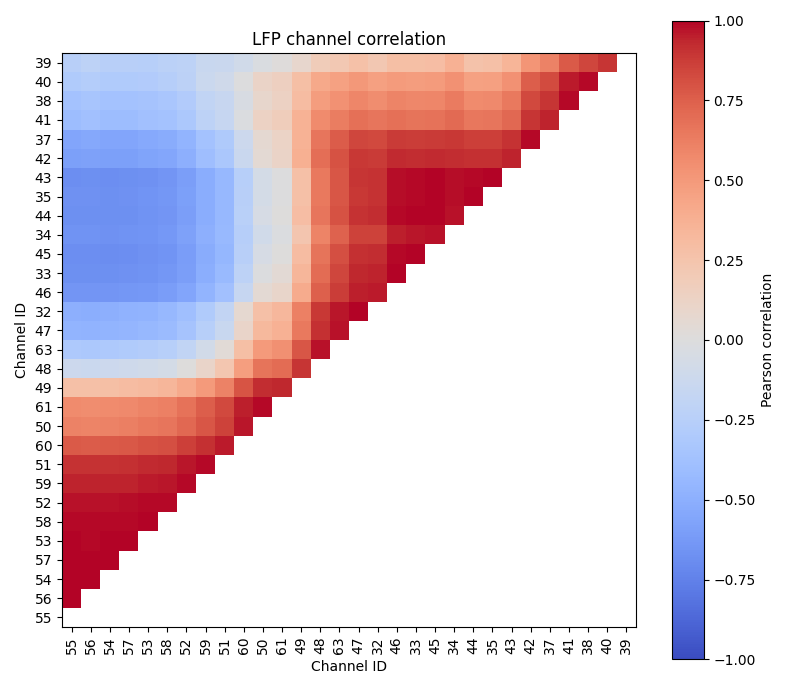

In [8]:
C = np.corrcoef(traces.T)
mask = np.triu(np.ones_like(C, dtype=bool))

C_masked = np.ma.masked_where(mask, C)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C_masked, aspect="equal", origin="lower", vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(np.arange(len(clean_channel_ids)))
ax.set_yticks(np.arange(len(clean_channel_ids)))

ax.set_xticklabels(clean_channel_ids, rotation=90)
ax.set_yticklabels(clean_channel_ids)

ax.set_xlabel("Channel ID")
ax.set_ylabel("Channel ID")
ax.set_title("LFP channel correlation")

fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

what we're seeing could be the polarity inversion across cortical layers 
oscillations :) 

channels within groups behave like neighbors 

In [3]:
KS_P1 = si.preprocessing.center(clean_recording, mode='mean', dtype='float32')

KS_P2 = si.preprocessing.highpass_filter(KS_P1, freq_min=300.0)

# JR clust uses median, KS4 uses average
KS_P3 = si.preprocessing.common_reference(recording = KS_P2, reference = 'global', operator='median')    # median may be better as its not sensitive to big spikes or bad channels / more robust 


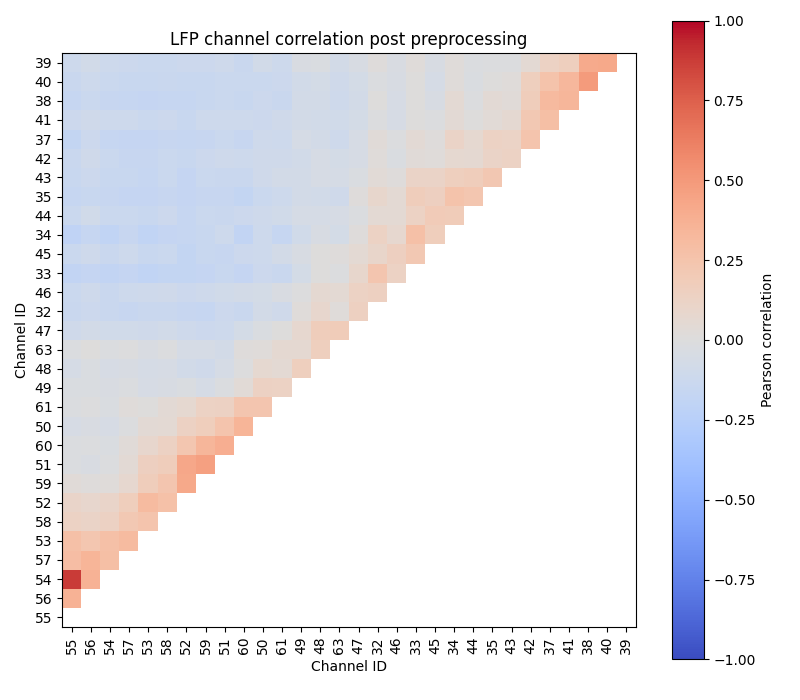

In [32]:
traces_preprocessed = KS_P3.get_traces(channel_ids=clean_channel_ids[:], start_frame=0, end_frame=10000, return_in_uV=True)  

C = np.corrcoef(traces_preprocessed.T)
mask = np.triu(np.ones_like(C, dtype=bool))

C_masked = np.ma.masked_where(mask, C)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C_masked, aspect="equal", origin="lower", vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(np.arange(len(clean_channel_ids)))
ax.set_yticks(np.arange(len(clean_channel_ids)))

ax.set_xticklabels(clean_channel_ids, rotation=90)
ax.set_yticklabels(clean_channel_ids)

ax.set_xlabel("Channel ID")
ax.set_ylabel("Channel ID")
ax.set_title("LFP channel correlation post preprocessing")

fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

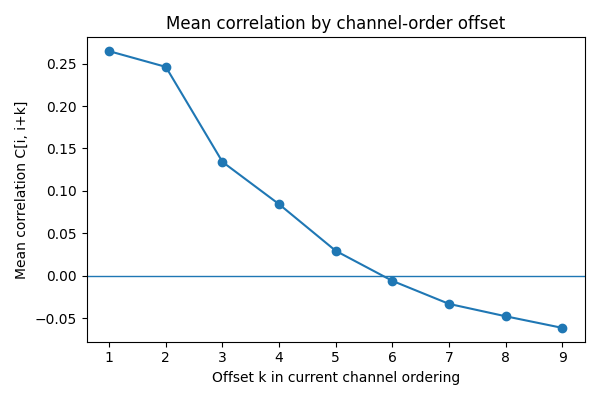

In [29]:
import numpy as np
import matplotlib.pyplot as plt

offset_corr = []

for k in range(1, 10):
    vals = []
    for i in range(len(C) - k):
        vals.append(C[i, i + k])
    offset_corr.append(np.mean(vals))

ks = np.arange(1, 10)

plt.figure(figsize=(6, 4))
plt.plot(ks, offset_corr, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Offset k in current channel ordering")
plt.ylabel("Mean correlation C[i, i+k]")
plt.title("Mean correlation by channel-order offset")
plt.xticks(ks)
plt.tight_layout()
plt.show()

ValueError: x and y must be the same size

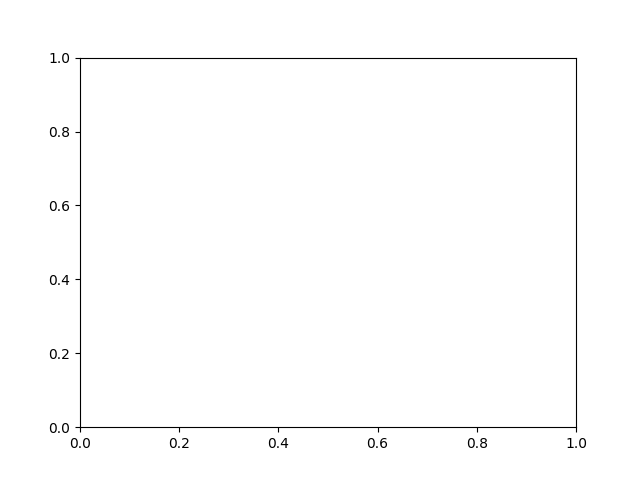

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

coords = np.c_[result.ends[:, 0], result.ends[:, 1]]
D = squareform(pdist(coords))

tri = np.triu_indices_from(D, k=1)

plt.figure(figsize=(6, 4))
plt.scatter(D[tri], C[tri], s=8, alpha=0.5)
plt.xlabel("Nominal distance [µm]")
plt.ylabel("Correlation")
plt.title("Correlation vs nominal contact distance")
plt.tight_layout()
plt.show()

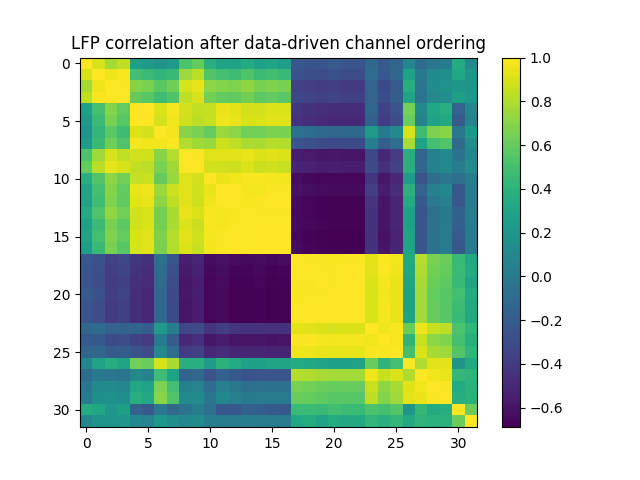

In [16]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist = 1 - C
np.fill_diagonal(dist, 0)

Z = linkage(squareform(dist, checks=False), method="average")
order = leaves_list(Z)

plt.figure()
plt.imshow(C[np.ix_(order, order)], aspect="auto")
plt.colorbar()
plt.title("LFP correlation after data-driven channel ordering")
plt.show()

In [ ]:
import spikeinterface.sorters as ss

MS5_params = {
    "filter": False,
    "whiten": True,
    "n_jobs": 4,
    "chunk_duration": "2s",
    "progress_bar": True,
    "detect_threshold": 7,
    "detect_sign": -1,
    "detect_time_radius_msec": 0.5,

    "snippet_T1": 20,
    "snippet_T2": 20,

    "npca_per_channel": 3,
    "snippet_mask_radius": 150,

    "scheme2_phase1_detect_channel_radius": 150,
    "scheme2_detect_channel_radius": 100,

    "max_threads_per_worker": 1,
}

sorting_MS5 = ss.run_sorter(
    sorter_name="mountainsort5",
    recording=KS_P3,
    folder="SI_SortingResults/MS5_May_18_2026",
    remove_existing_folder=True,
    verbose=True,
    **MS5_params
)

whitening
write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=40,000 - chunk_memory=4.58 MiB - total_memory=18.31 MiB - chunk_duration=2.00s


write_binary_recording (workers: 4 processes spawn):   0%|          | 0/1898 [00:00<?, ?it/s]

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.309 seconds ***
Running phase 1 sorting
Number of channels: 30
Number of timepoints: 6000000
Sampling frequency: 20000.0 Hz
Channel 0: [534.21525    784.99608185]
Channel 1: [498.08475    765.49608185]
Channel 2: [533.04975    723.84959779]
Channel 3: [499.25025    704.34959779]
Channel 4: [531.88425    664.15654519]
Channel 5: [500.41575    644.65654519]
Channel 6: [530.71875    605.90393326]
Channel 7: [501.58125    586.40393326]
Channel 8: [529.55325    549.08286865]
Channel 9: [502.74675    529.58286865]
Channel 10: [528.38775    493.68836816]
Channel 11: [503.91225    474.18836816]
Channel 12: [527.22225   439.7192096]
Channel 13: [526.05675    387.17781774]
Channel 14: [506.24325    367.67781774]
Channel 15: [524.89125    336.07018235]
Channel 16: [507.40875    316.57018235]
Channel 17: [523.72575    286.40580649]
Channel 18: [508.5742

In [5]:
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_MS5, clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

estimate_sparsity (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]

compute_waveforms (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/4 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\social\Desktop\temp_Brune\spikeinterface\venv_SI\Lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


spike_amplitudes (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

In [6]:
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

In [ ]:
sorting_HS = ss.run_sorter(
    sorter_name="herdingspikes",
    recording=KS_P3,
    folder="SI_SortingResults/HS_May_18_2026",
    remove_existing_folder=True,
    verbose=True,
)



Chunk size not set, setting to 666666 samples.
HSDetection: Analysing segment 0, frames from        0 to   666666  (0.0%)
HSDetection: Analysing segment 0, frames from   666666 to  1333332  (0.9%)
HSDetection: Analysing segment 0, frames from  1333332 to  1999998  (1.8%)
HSDetection: Analysing segment 0, frames from  1999998 to  2666664  (2.6%)
HSDetection: Analysing segment 0, frames from  2666664 to  3333330  (3.5%)
HSDetection: Analysing segment 0, frames from  3333330 to  3999996  (4.4%)
HSDetection: Analysing segment 0, frames from  3999996 to  4666662  (5.3%)
HSDetection: Analysing segment 0, frames from  4666662 to  5333328  (6.1%)
HSDetection: Analysing segment 0, frames from  5333328 to  5999994  (7.0%)
HSDetection: Analysing segment 0, frames from  5999994 to  6666660  (7.9%)
HSDetection: Analysing segment 0, frames from  6666660 to  7333326  (8.8%)
HSDetection: Analysing segment 0, frames from  7333326 to  7999992  (9.7%)
HSDetection: Analysing segment 0, frames from  799999

[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   3 out of  32 | elapsed:    4.7s remaining:   46.0s
[Parallel(n_jobs=32)]: Done  20 out of  32 | elapsed:    5.1s remaining:    3.0s
[Parallel(n_jobs=32)]: Done  32 out of  32 | elapsed:    5.3s finished


Number of estimated units: 163
Saving to c:\Users\social\Desktop\temp_Brune\SpikeExplore\SI_SortingResults\HS_May_18_2026\sorter_output\HS2_sorted.hdf5
# Sampling rate: 20000.0.
herdingspikes run time 138.56s


'sorting_TDC = ss.run_sorter(\n    sorter_name="tridesclous",\n    recording=KS_P3,\n    folder="SI_SortingResults/TDC_May_18_2026",\n    remove_existing_folder=True,\n    verbose=True,\n)'

In [9]:
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_HS, clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

estimate_sparsity (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]

compute_waveforms (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/163 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/163 [00:00<?, ?it/s]

spike_amplitudes (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

In [10]:
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

In [ ]:
sorting_TDC = ss.run_sorter(
    sorter_name="tridesclous",
    recording=KS_P3,
    folder="SI_SortingResults/TDC_May_18_2026",
    remove_existing_folder=True,
    verbose=True)

Local copy of recording


write_binary_recording (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]